# Пример расследования: «Поймай статистику, которая врёт»
### YDL 2026 · фрилансеры · разбор

Перед нами `ydl_freelancers.csv`, выдуманные данные о 221 фрилансере: специализация, город, возраст,
опыт в месяцах, часы в неделю, доход, рейтинг от клиентов, отметка об отклике на опрос и несколько
шумовых колонок.

Правило игры одно: **мы не верим ни одному числу, пока не проверили, откуда оно взялось.**
Ниже мы пройдём задание лабы по шагам и поймаем пять разных способов, которыми статистика врёт.

In [1]:
import pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv('ydl_freelancers.csv')
print('строк:', len(df), '  колонок:', df.shape[1])
df.head()

строк: 221   колонок: 16


,specialization,city,age,experience_months,weekly_hours,income,rating,responded,noise1,noise2,noise3,noise4,noise5,noise6,noise7,noise8
0,Веб-разработка,Алматы,36,49,39.6,579000,5.4,1,-0.975,0.504,1.748,0.357,-1.066,0.666,0.223,0.099
1,Аналитика данных,Алматы,28,1,29.2,1135000,4.4,0,-0.196,-0.006,-1.894,-1.802,-0.565,0.031,-2.523,-0.395
2,Веб-разработка,Алматы,22,11,32.7,404000,NaN,0,0.583,-1.593,-0.616,2.281,-0.911,-1.367,0.226,-0.523
3,Аналитика данных,Алматы,24,44,23.1,759000,NaN,1,-1.267,0.081,1.106,-1.024,0.102,-0.489,-0.490,-0.116
4,Аналитика данных,Алматы,40,24,18.3,685000,NaN,0,-1.187,1.188,-0.402,1.980,0.067,-1.015,0.627,-0.525


In [2]:
df['specialization'].unique()

array(['Веб-разработка', 'Аналитика данных', 'Дизайн', 'Своё агентство'],
      dtype=object)

In [3]:
df['specialization'].value_counts()

specialization
Веб-разработка      82
Аналитика данных    70
Дизайн              60
Своё агентство       9
Name: count, dtype: int64

## Задание 1. Допросите одну колонку: доход

Считаем сводку. Не глядим на неё как на формальность, сравниваем среднее и медиану.

In [4]:
df['income'].describe().round(0)

count        221.0
mean      768670.0
std       744997.0
min       271000.0
25%       440000.0
50%       589000.0
75%       859000.0
max      5091000.0
Name: income, dtype: float64

In [5]:
print('среднее :', round(df.income.mean()))
print('медиана :', round(df.income.median()))
print('отношение среднее/медиана:', round(df.income.mean()/df.income.median(), 2))

среднее : 768670
медиана : 589000
отношение среднее/медиана: 1.31


### Ловушка №1: среднее завышено перекосом

Среднее (около 769 000) заметно больше медианы (около 589 000). Когда они так расходятся, данные
перекошены, и среднее уже не «типичный фрилансер». Посмотрим на гистограмму и на тех, кто тянет хвост.

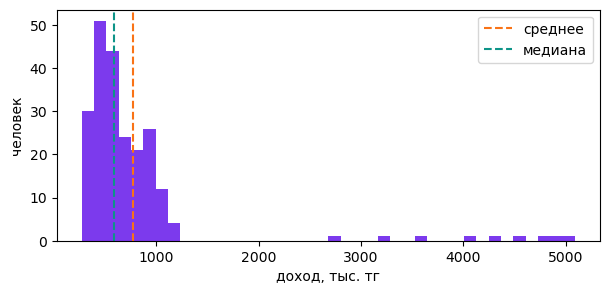

In [6]:
fig, ax = plt.subplots(figsize=(7,3))
ax.hist(df.income/1000, bins=40, color='#7C3AED')
ax.axvline(df.income.mean()/1000, color='#F97316', linestyle='--', label='среднее')
ax.axvline(df.income.median()/1000, color='#0D9488', linestyle='--', label='медиана')
ax.set_xlabel('доход, тыс. тг'); ax.set_ylabel('человек'); ax.legend()
plt.show()

In [7]:
# проверяем руками: кто в правом хвосте?
df.nlargest(9, 'income')[['specialization','weekly_hours','income']]

,specialization,weekly_hours,income
70,Своё агентство,36.5,5091000
159,Своё агентство,25.8,4872000
163,Своё агентство,28.6,4743000
74,Своё агентство,29.7,4530000
81,Своё агентство,32.5,4329000
35,Своё агентство,28.1,4089000
170,Своё агентство,30.4,3554000
30,Своё агентство,30.3,3283000
83,Своё агентство,41.9,2690000


Хвост это девять человек из специализации «Своё агентство» с доходами в миллионы. Их всего 9 из 221,
но они утягивают среднее вверх. Честный ответ про «типичного фрилансера» даёт **медиана**.

То же видно через группировку: средняя по «Своё агентство» огромная, и она искажает общую среднюю.

In [8]:
df.groupby('specialization')['income'].agg(['count','mean','median']).round(0)

,count,mean,median
specialization,,,
Аналитика данных,70,902943.0,894500.0
Веб-разработка,82,558744.0,567500.0
Дизайн,60,394533.0,398500.0
Своё агентство,9,4131222.0,4329000.0


## Ловушка №2: пропуски, которые молчат

Посчитаем средний рейтинг. Но сначала спросим: по скольким строкам он вообще считается?

In [9]:
print('средний рейтинг:', round(df.rating.mean(), 2))
print('ответили:', df.rating.notna().sum(), '   молчат:', df.rating.isna().sum())

средний рейтинг: 6.48
ответили: 138    молчат: 83


In [10]:
# кто именно не оставил рейтинг? сравним доход ответивших и молчащих
df.groupby(df.rating.isna())['income'].median().rename({False:'ответили', True:'молчат'}).round(0)

rating
ответили    688500.0
молчат      479000.0
Name: income, dtype: float64

Рейтинг «6.5» посчитан не по всем. Молчат в основном люди с низким доходом, а это как раз те, у кого
дела идут хуже. Среднее по ответившим выглядит хорошо именно потому, что неуспешные выпали из выборки.
Число честное по арифметике, но врёт по сути.

## Задание 2. Одна корреляция: часы и доход

In [11]:
r = df['weekly_hours'].corr(df['income'])
print('корреляция часов и дохода по всем данным: r =', round(r, 2))

корреляция часов и дохода по всем данным: r = -0.33


### Ловушка №3: парадокс Симпсона

Получилось `r = -0.33`. Буквально: чем больше человек работает, тем меньше зарабатывает. Звучит дико,
поэтому не верим и режем по специализации.

In [12]:
df.groupby('specialization')[['weekly_hours', 'income']].apply(
    lambda g: round(g.weekly_hours.corr(g.income), 2)
).rename('r внутри специализации')

specialization
Аналитика данных    0.80
Веб-разработка      0.78
Дизайн              0.81
Своё агентство     -0.47
Name: r внутри специализации, dtype: float64

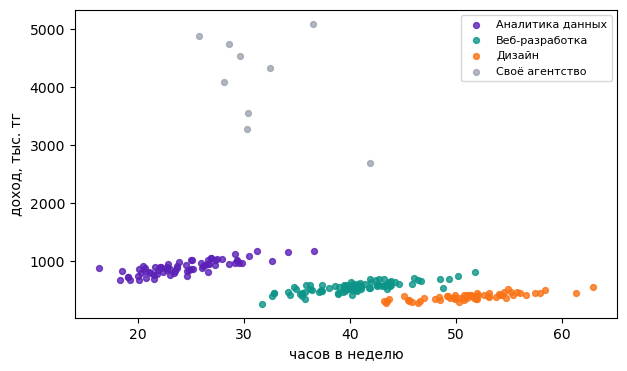

In [13]:
# покажем глазами: внутри каждой специализации связь идёт вверх, а общий тренд вниз
colors = {'Аналитика данных':'#5B21B6','Веб-разработка':'#0D9488',
          'Дизайн':'#F97316','Своё агентство':'#9CA3AF'}
fig, ax = plt.subplots(figsize=(7,4))
for sp, g in df.groupby('specialization'):
    ax.scatter(g.weekly_hours, g.income/1000, s=18, color=colors[sp], label=sp, alpha=0.8)
ax.set_xlabel('часов в неделю'); ax.set_ylabel('доход, тыс. тг'); ax.legend(fontsize=8)
plt.show()

Внутри каждой специализации связь **положительная** (около +0.8): больше часов, выше доход. Но
специализации стоят лесенкой: аналитики работают меньше часов и получают больше, дизайнеры наоборот.
Когда мы смешали всех в одну кучу, эта лесенка перевернула общий знак. Это парадокс Симпсона. Вывод
«больше работаешь, меньше платят» был артефактом смешения групп.

## Ловушка №4: смещение выборки

Представим, что доход мы узнали из опроса, и берём только тех, кто откликнулся.

In [14]:
print('средний по всем          :', round(df.income.mean()))
print('средний по откликнувшимся :', round(df[df.responded==1].income.mean()))
print('завышение опроса          :', str(round(100*(df[df.responded==1].income.mean()/df.income.mean()-1)))+'%')

средний по всем          : 768670
средний по откликнувшимся : 879483
завышение опроса          : 14%


Опрос показывает доход примерно на 14% выше реального. Причина: охотнее отвечают те, у кого
доход высокий. Это тот же «опрос выживших», кривая выборка дала кривой вывод.

## Бонус: z-score и выбросы

Стандартизуем доход и вытащим точки, где значение далеко от среднего.

In [15]:
z = (df.income - df.income.mean()) / df.income.std()
df.assign(z=z.round(2)).loc[z.abs() > 3, ['specialization','weekly_hours','income','z']]

,specialization,weekly_hours,income,z
30,Своё агентство,30.3,3283000,3.37
35,Своё агентство,28.1,4089000,4.46
70,Своё агентство,36.5,5091000,5.80
74,Своё агентство,29.7,4530000,5.05
81,Своё агентство,32.5,4329000,4.78
159,Своё агентство,25.8,4872000,5.51
163,Своё агентство,28.6,4743000,5.33
170,Своё агентство,30.4,3554000,3.74


Все выбросы это «Своё агентство». Те самые девять человек, что портили среднюю в Задании 1. z-score
нашёл их автоматически.

## Особый вызов: охота на призрак

В данных есть восемь чисто случайных колонок `noise1` ... `noise8`. Они ни с чем не связаны по
построению. Переберём все их пары и поищем самую «значимую» корреляцию.

In [16]:
noise = [f'noise{i}' for i in range(1, 9)]
res = []
for i in range(len(noise)):
    for j in range(i+1, len(noise)):
        r, p = stats.pearsonr(df[noise[i]], df[noise[j]])
        res.append((noise[i], noise[j], round(r, 3), round(p, 3)))
res = pd.DataFrame(res, columns=['A','B','r','p']).sort_values('p')
res.head(5)

,A,B,r,p
21,noise4,noise8,0.160,0.017
22,noise5,noise6,-0.138,0.040
25,noise6,noise7,-0.122,0.070
26,noise6,noise8,0.116,0.085
4,noise1,noise6,0.110,0.103


Лучшая пара даёт `r ≈ 0.16` и `p ≈ 0.02`, формально «значимо» (p меньше 0.05). Но мы своими руками
сделали эти колонки случайными, связи там нет. Мы просто проверили 28 пар, и пара случайно прошла порог.

Это **p-hacking**: если перебрать достаточно гипотез, что-нибудь всегда выскочит «значимым». Именно так
рождаются ложные открытия, и ровно поэтому модель с R² = 0.99 на подогнанных признаках может оказаться
пустышкой. Самое ценное здесь не найденная корреляция, а понимание, почему ей нельзя верить.

## Что мы поймали

1. **Среднее дохода** завышено горсткой агентств. Честный ответ даёт медиана.
2. **Средний рейтинг** посчитан без неуспешных, они просто не ответили.
3. **Корреляция часов и дохода** перевернулась из-за смешения специализаций (парадокс Симпсона).
4. **Опрос** завысил доход, потому что отвечали в основном высокодоходные.
5. **«Значимая» корреляция** между случайными колонками оказалась призраком (p-hacking).

Пять чисел, и каждое звучало убедительно. Ни одному нельзя было верить без проверки. Это и есть работа
сегодняшнего дня.